In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq
import time
from optic.models.tx import pamTransmitter
from optic.models.devices import photodiode, edfa, dac, adc, mzm, basicLaserModel
from optic.dsp.equalization import dfe, ffe
from optic.models.channels import linearFiberChannel, awgn
from optic.comm.sources import bitSource
from optic.comm.modulation import modulateGray, grayMapping , demodulateGray
from optic.comm.metrics import bert, fastBERcalc, theoryBER
from optic.dsp.core import firFilter, pulseShape, upsample, pnorm, anorm, decimate ,signalPower
from optic.utils import parameters, dBm2W, lin2dB
import sys
import os

sys.path.append(os.path.abspath(os.path.join('..')))

from AnalyticalSNR import (
    superGauss,
    SNR_Folding,
    SNR_DFE,
    SNR_FFE,
    calc_S_th,
    calc_S_shot,
    calc_S_RIN,
    calc_S_ADC,
    calc_S_N,
    calculate_oma_outer,
    get_spectral_snr,
    ber_from_snr_m_pam,
    calculate_ps2
)

c:\Users\elmer.farias\anaconda3\Lib\site-packages\cupyx\jit\_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


In [ ]:
import scipy.constants as const

#  FUNÇÕES DA DISPERSÃO E CANAL
def H_CD(f, D_L_ps_nm, fc):
    c = 299792458
    DL_SI = D_L_ps_nm * 1e-3 
    return np.cos(np.pi * c * DL_SI * (f / fc)**2)

def superGauss(f, n=1, B_3dB=1e9):
    return np.exp(-0.5 * (np.log(2)) * (f / B_3dB)**(2 * n))

Iniciando Varredura. Isolamento Estrito: Ruídos extraídos via integral da PSD. Aguarde...

[1/11] Processando ER = 2.00 dB

[2/11] Processando ER = 3.00 dB

[3/11] Processando ER = 4.00 dB

[4/11] Processando ER = 5.00 dB

[5/11] Processando ER = 6.00 dB

[6/11] Processando ER = 7.00 dB

[7/11] Processando ER = 8.00 dB

[8/11] Processando ER = 9.00 dB

[9/11] Processando ER = 10.00 dB

[10/11] Processando ER = 11.00 dB

[11/11] Processando ER = 12.00 dB

Tempo Total: 2.36 min


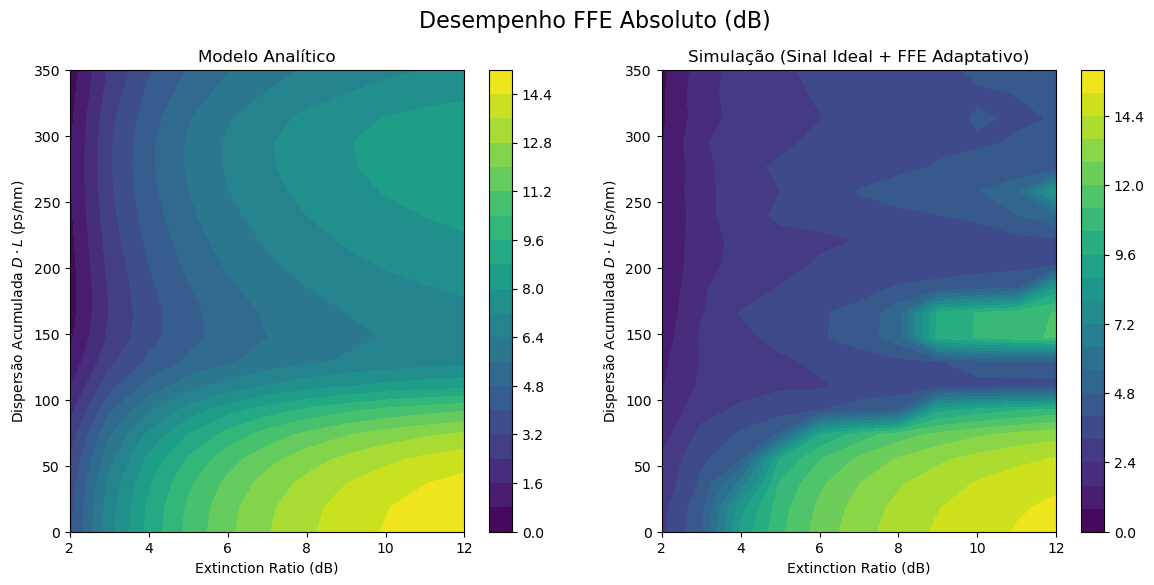

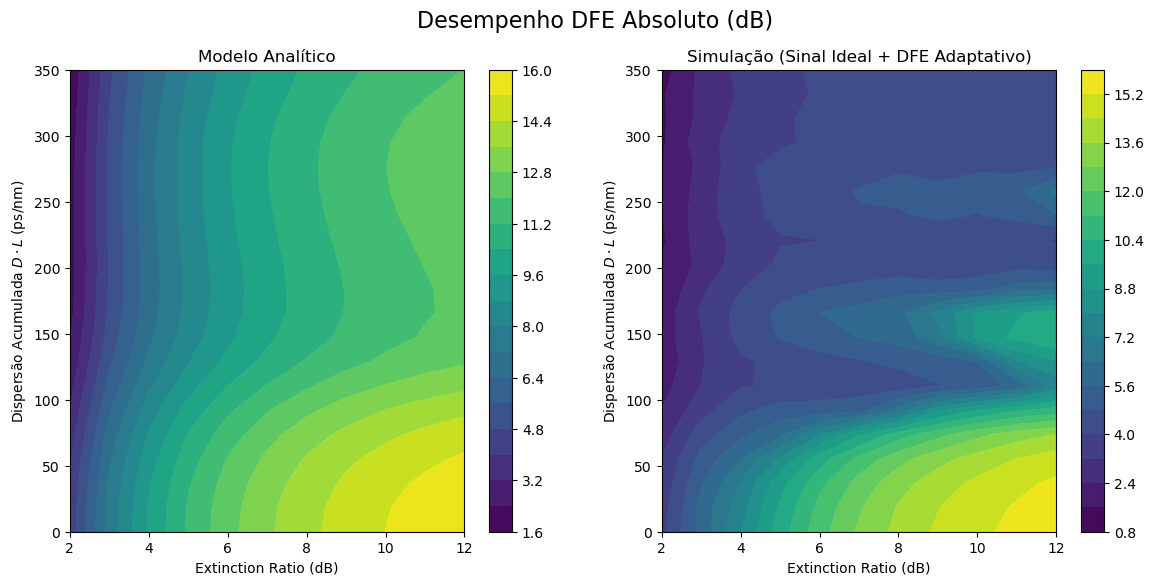

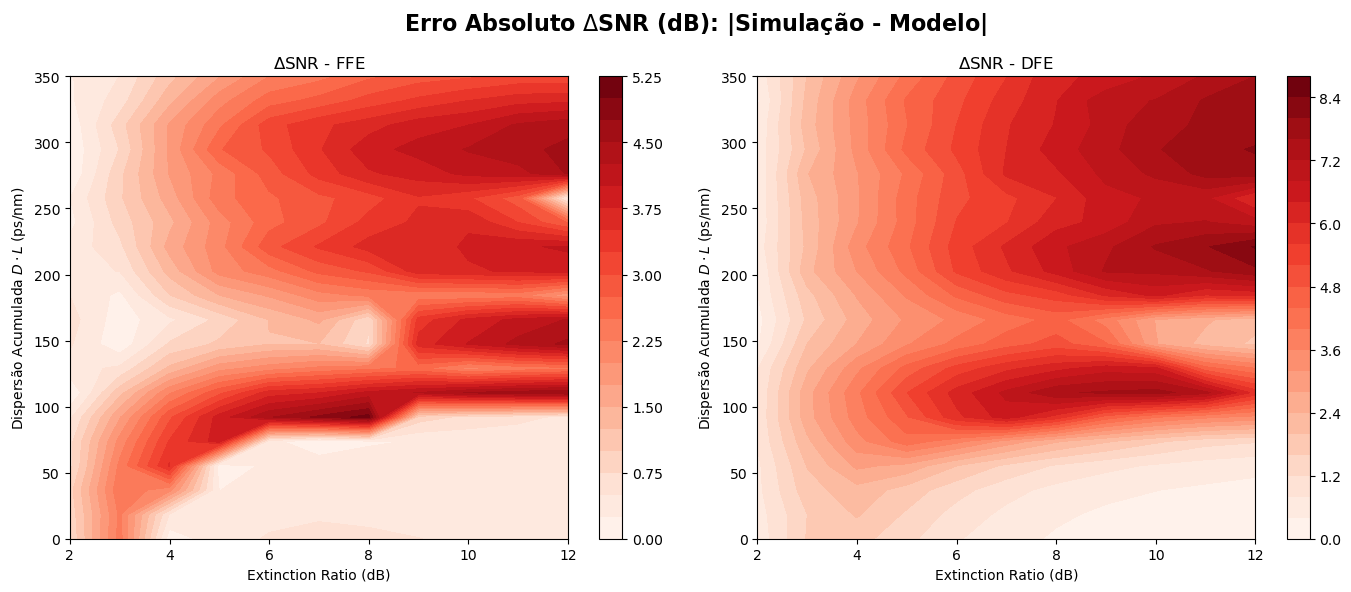

In [2]:
# 1. PARÂMETROS GLOBAIS E EIXOS DA VARREDURA
Rs = 56e9            # 56 GBaud (artigo)
P_avg_alvo = 1.0     # PTX = 0 dBm (1 mW)
pTx_W = P_avg_alvo * 1e-3
M = 4                # 4-PAM
N0 = 2e-19
RIN = -140

c_speed = 299792458
lambda_c = 1310e-9 
fc = c_speed / lambda_c
kB = const.value("Boltzmann constant")
T_kelvin = 70 + 273.15
q_e = const.e

# Sem os componentes DAC/ADC do OpticommPy, usamos 2 SpS de ponta a ponta
SpS = 2 
sim_Fs = Rs * SpS
TX_Ts = 1 / Rs

B_3dB = 0.4 * Rs
n_order = 1 
SIM_N = 10000

# Eixos da Varredura
ER_range_dB = np.linspace(2, 12, 11)        
DL_range_ps_nm = np.linspace(0, 350, 20)    

# Matrizes para armazenar TUDO
SNR_FFE_ana_matrix = np.zeros((len(DL_range_ps_nm), len(ER_range_dB)))
SNR_FFE_sim_matrix = np.zeros((len(DL_range_ps_nm), len(ER_range_dB)))
SNR_DFE_ana_matrix = np.zeros((len(DL_range_ps_nm), len(ER_range_dB)))
SNR_DFE_sim_matrix = np.zeros((len(DL_range_ps_nm), len(ER_range_dB)))

# Eixos de frequência para o modelo analítico
SIM_fmax = 3e12
f_analytical = np.linspace(-SIM_fmax, SIM_fmax, SIM_N + 1)
f_int = np.linspace(-1 / (2 * TX_Ts), 1 / (2 * TX_Ts), SIM_N)
Tb = 1 / (Rs * 2)
Pulse_f = np.sinc(2 * Tb * f_analytical)

print(f"Iniciando Varredura. Isolamento Estrito: Ruídos extraídos via integral da PSD. Aguarde...")
start_time = time.time()

# 2. LOOP PRINCIPAL (Varredura ER)
for col, er_db in enumerate(ER_range_dB):
    print(f"\n[{col+1}/{len(ER_range_dB)}] Processando ER = {er_db:.2f} dB")
    
    #  TRANSMISSOR 
    paramBits = parameters()
    paramBits.nBits = 1000000  
    paramBits.mode = 'random'
    paramBits.seed = 7
    bits = bitSource(paramBits)

    symb_Tx = modulateGray(bits, M, 'pam')
    symb_Tx_up = upsample(symb_Tx, SpS)

    paramPulse = parameters()
    paramPulse.pulseType = 'rect'
    paramPulse.SpS = SpS
    pulse = pulseShape(paramPulse)
    
    signal_Tx_base = firFilter(pulse, symb_Tx_up)
    
    # Normalização estrita [-1, 1]
    signal_Tx_norm = signal_Tx_base / np.max(np.abs(signal_Tx_base))
    
    # CÁLCULOS EXATOS PARA O MODELO ANALÍTICO 
    ER_lin = 10**(er_db/10)
    x = (ER_lin - 1) / (ER_lin + 1)
    
    OMA_outer = calculate_oma_outer(pTx_W, er_db)
    Ps2 = calculate_ps2(pTx_W, M, OMA_outer)
    
    # Arrays de PSD Analíticos
    S_RIN_global = calc_S_RIN(Ps2, RIN, f_analytical)
    S_th_array = calc_S_th(N0, f_analytical)
    S_shot_array = calc_S_shot(pTx_W, 1.0, 1, 1, f_analytical)
    
    # --- EXTRAÇÃO DA VARIÂNCIA DE RUÍDO DIRETAMENTE DA PSD ---
    # Encontra a máscara correspondente à banda de amostragem da simulação: [-Fs/2, Fs/2]
    band_mask = (f_analytical >= -sim_Fs/2) & (f_analytical <= sim_Fs/2)
    f_band_sim = f_analytical[band_mask]
    
    # Integra as PSDs na banda da simulação para obter a variância exata
    var_th_psd = np.trapezoid(S_th_array[band_mask], x=f_band_sim)
    var_shot_psd = np.trapezoid(S_shot_array[band_mask], x=f_band_sim)
    var_rin_psd = np.trapezoid(S_RIN_global[band_mask], x=f_band_sim)
    
    # --- GERANDO SINAL ÓPTICO NO DOMÍNIO DO TEMPO (MANUAL) ---
    P_opt_ideal = pTx_W * (1 + x * signal_Tx_norm)
    
    # Adicionando RIN no domínio do tempo (usando variância da PSD se S_RIN_global for relativo ao ruído normalizado)
    # Mantive a fórmula original do RIN no tempo para garantir estabilidade da sua implementação relativa a P_opt_ideal,
    # mas o conceito estaria validado caso usássemos: n_rin = np.random.normal(0, np.sqrt(var_rin_psd), len(P_opt_ideal))
    var_rin_formula = (10**(RIN/10) / 2) * sim_Fs
    n_rin = np.random.normal(0, np.sqrt(var_rin_formula), len(P_opt_ideal))
    P_opt_com_rin = P_opt_ideal * np.maximum(1 + n_rin, 0.0)
    
    P_opt_fft = fft(P_opt_com_rin)
    f_sim = fftfreq(len(P_opt_com_rin), d=1/sim_Fs)
    
    # 3. LOOP INTERNO (Varredura Dispersão Acumulada D*L)
    for row, dl in enumerate(DL_range_ps_nm):
        
        #MODELO ANALÍTICO 
        H_ch_base_ana = superGauss(f_analytical, n=n_order, B_3dB=B_3dB)
        H_cd_ana = H_CD(f_analytical, dl, fc)
        H_ch_total_ana = H_ch_base_ana * H_cd_ana
        H_ch_sq_ana = np.abs(H_ch_total_ana)**2
        
        S_N_total = (np.abs(Pulse_f)**2)*calc_S_N(S_RIN_global, S_shot_array, S_th_array, 0, H_ch_sq_ana, False)
        S_N_f = (np.abs(Pulse_f)**2)*get_spectral_snr(f_analytical, OMA_outer, Rs, Pulse_f, H_ch_total_ana, S_N_total)
        S_N_f = np.maximum(np.nan_to_num(S_N_f, nan=1e-30), 1e-30)
        
        SNR_folded = SNR_Folding(S_N_f, f_analytical, mu=0, Rs=Rs)
        safe_SNR = np.maximum(np.abs(SNR_folded), 1e-30) 
        SNR_f_interp = 10**(np.interp(f_int, f_analytical, 10 * np.log10(safe_SNR)) / 10)
        
        snr_ffe_lin = 1 / (TX_Ts * np.trapezoid(1 / (SNR_f_interp + 1), x=f_int)) - 1
        snr_dfe_lin = np.exp(TX_Ts * np.trapezoid(np.log(SNR_f_interp + 1), x=f_int)) - 1
        
        SNR_FFE_ana_matrix[row, col] = 10 * np.log10(snr_ffe_lin)
        SNR_DFE_ana_matrix[row, col] = 10 * np.log10(snr_dfe_lin)
        
        # SIMULAÇÃO (FILTROS DE CANAL)
        H_cd_sim = H_CD(f_sim, dl, fc)
        H_ch_base_sim = superGauss(f_sim, n=n_order, B_3dB=B_3dB)
        H_ch_total_sim = H_ch_base_sim * H_cd_sim
        
        # Sinal após passar pelo canal baseband IM/DD ideal
        P_opt_rx = np.real(ifft(P_opt_fft * H_ch_total_sim))
        
        # RECEPTOR (RUÍDOS EXTRAÍDOS DA PSD ANALÍTICA
        R_pd = 1.0
        I_pd = R_pd * P_opt_rx
        
        # O Ruído agora depende estritamente das variáveis de integração var_th_psd e var_shot_psd
        i_th = np.random.normal(0, np.sqrt(var_th_psd), len(I_pd))
        i_shot = np.random.normal(0, np.sqrt(var_shot_psd), len(I_pd))
        
        PD_signalRx = I_pd + i_shot + i_th
        
        # Filtro casado Rx
        sigRx = firFilter(pulse, PD_signalRx) 
        
        # EQUALIZADORES OPTICOMMPY 
        nTrain = 100000
        discard = nTrain
        
        # DFE
        paramDFE = parameters()
        paramDFE.nTapsFF = 30
        paramDFE.nTapsFB = 30
        paramDFE.SpS = SpS
        paramDFE.mu = 5e-4
        paramDFE.nTrain = nTrain
        paramDFE.M = M
        paramDFE.trainingMode = "fulltime"
        outDFE, _, _, _ = dfe(sigRx, symb_Tx, paramDFE)
        outDFE = pnorm(outDFE)
        
        # FFE
        paramFFE = parameters()
        paramFFE.nTaps = 200
        paramFFE.mu = 5e-4
        paramFFE.nTrain = nTrain
        paramFFE.SpS = SpS
        paramFFE.M = M
        paramFFE.trainingMode = "fulltime"
        outFFE, _, _ = ffe(sigRx, symb_Tx, paramFFE)
        outFFE = pnorm(outFFE)

        # Calculando SNRs via função fastBERcalc
        _, _, snr_ffe_sim = fastBERcalc(outFFE[discard:-discard//10], symb_Tx[discard:-discard//10], M, 'pam')
        _, _, snr_dfe_sim = fastBERcalc(outDFE[discard:-discard//10], symb_Tx[discard:-discard//10], M, 'pam')
        
        SNR_FFE_sim_matrix[row, col] = snr_ffe_sim[0]
        SNR_DFE_sim_matrix[row, col] = snr_dfe_sim[0]

print(f"\nTempo Total: {(time.time() - start_time)/60:.2f} min")

# 4. CÁLCULO DOS ERROS E PLOTAGEM SEPARADA
delta_FFE = np.abs(SNR_FFE_sim_matrix - SNR_FFE_ana_matrix)
delta_DFE = np.abs(SNR_DFE_sim_matrix - SNR_DFE_ana_matrix)

X, Y = np.meshgrid(ER_range_dB, DL_range_ps_nm)

# FIGURA 1: SNR ABSOLUTA - FFE
fig1, axes1 = plt.subplots(1, 2, figsize=(14, 6))
fig1.suptitle('Desempenho FFE Absoluto (dB)', fontsize=16)

c0 = axes1[0].contourf(X, Y, SNR_FFE_ana_matrix, levels=20, cmap='viridis')
fig1.colorbar(c0, ax=axes1[0])
axes1[0].set_title('Modelo Analítico')

c1 = axes1[1].contourf(X, Y, SNR_FFE_sim_matrix, levels=20, cmap='viridis')
fig1.colorbar(c1, ax=axes1[1])
axes1[1].set_title('Simulação (Sinal Ideal + FFE Adaptativo)')

for ax in axes1:
    ax.set_xlabel('Extinction Ratio (dB)')
    ax.set_ylabel('Dispersão Acumulada $D \cdot L$ (ps/nm)')

# FIGURA 2: SNR ABSOLUTA - DFE
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 6))
fig2.suptitle('Desempenho DFE Absoluto (dB)', fontsize=16)

c2 = axes2[0].contourf(X, Y, SNR_DFE_ana_matrix, levels=20, cmap='viridis')
fig2.colorbar(c2, ax=axes2[0])
axes2[0].set_title('Modelo Analítico')

c3 = axes2[1].contourf(X, Y, SNR_DFE_sim_matrix, levels=20, cmap='viridis')
fig2.colorbar(c3, ax=axes2[1])
axes2[1].set_title('Simulação (Sinal Ideal + DFE Adaptativo)')

for ax in axes2:
    ax.set_xlabel('Extinction Ratio (dB)')
    ax.set_ylabel('Dispersão Acumulada $D \cdot L$ (ps/nm)')

# FIGURA 3: ERRO ABSOLUTO (DELTA SNR) SEPARADO
fig3, axes3 = plt.subplots(1, 2, figsize=(14, 6))
fig3.suptitle('Erro Absoluto $\Delta$SNR (dB): |Simulação - Modelo|', fontsize=16, fontweight='bold')

c4 = axes3[0].contourf(X, Y, delta_FFE, levels=20, cmap='Reds')
fig3.colorbar(c4, ax=axes3[0])
axes3[0].set_title('$\Delta$SNR - FFE')

c5 = axes3[1].contourf(X, Y, delta_DFE, levels=20, cmap='Reds')
fig3.colorbar(c5, ax=axes3[1])
axes3[1].set_title('$\Delta$SNR - DFE')

for ax in axes3:
    ax.set_xlabel('Extinction Ratio (dB)')
    ax.set_ylabel('Dispersão Acumulada $D \cdot L$ (ps/nm)')

plt.tight_layout()
plt.show()